# Calories Burnt Prediction — Standardized ML Pipeline

Predict **Calories** burnt during exercise (regression) using a clean, leakage-free pipeline.

**Pipeline order:** Basic Analysis -> Train/Test Split -> EDA -> Feature Engineering -> Encoding -> Outlier Handling -> Scaling -> Models.

> The data comes in two files: `exercise.csv` (features) and `calories.csv` (the target). We merge them on `User_ID`. Every data-driven step is fit on the **training set only**.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base = '/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Burn Calories Prediction/'

exercise = pd.read_csv(base + 'exercise.csv')
calories = pd.read_csv(base + 'calories.csv')

# merge features with the target on User_ID, then drop the ID (not a predictor)
df = exercise.merge(calories, on='User_ID')
df = df.drop(columns='User_ID')
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
print('Shape:', df.shape)
df.info()

Shape: (15000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [5]:
df.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


## 2. Train-Test Split (done early to prevent data leakage)

In [7]:
X = df.drop(columns='Calories')
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (12000, 7) | Test: (3000, 7)


## 3. EDA (training data only)

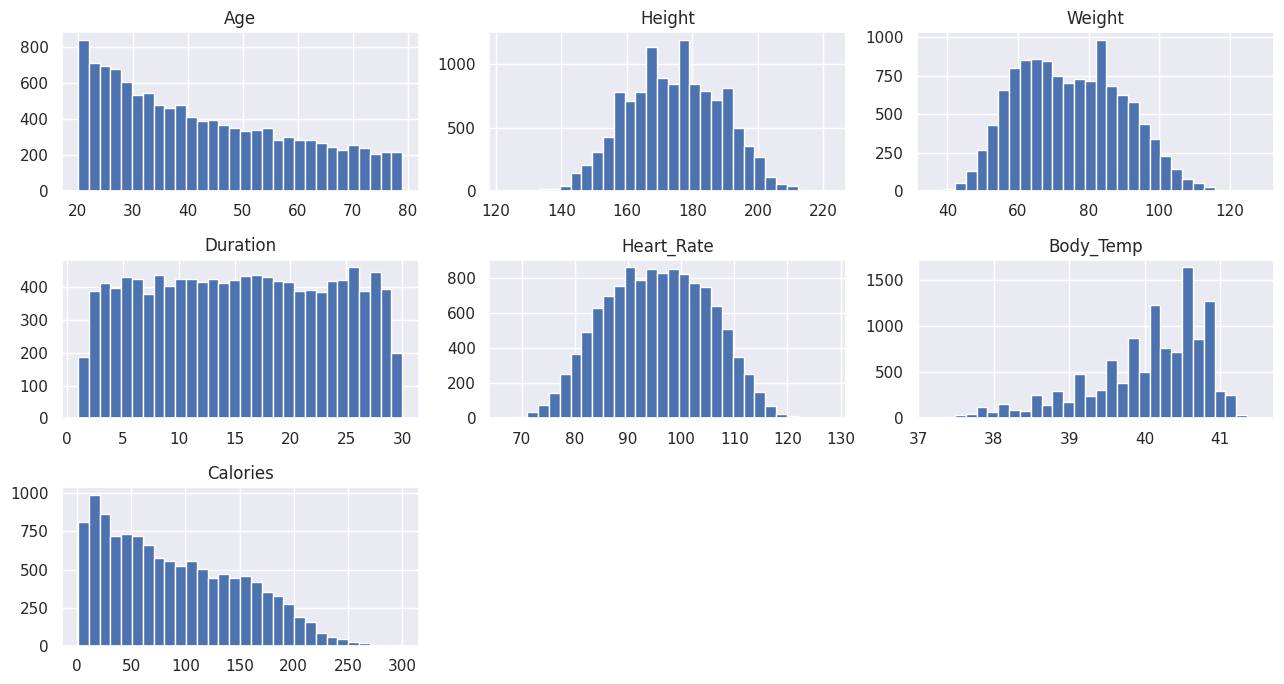

In [8]:
train_df = X_train.copy()
train_df['Calories'] = y_train

num_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
train_df[num_cols].hist(figsize=(13, 7), bins=30)
plt.tight_layout()
plt.show()

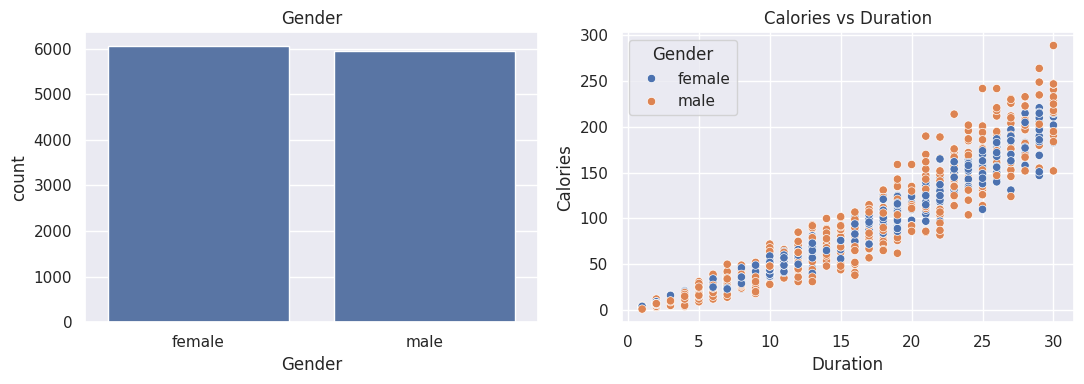

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Gender', data=train_df, ax=axes[0])
axes[0].set_title('Gender')
sample = train_df.sample(min(1000, len(train_df)), random_state=2)
sns.scatterplot(x='Duration', y='Calories', hue='Gender', data=sample, ax=axes[1])
axes[1].set_title('Calories vs Duration')
plt.tight_layout()
plt.show()

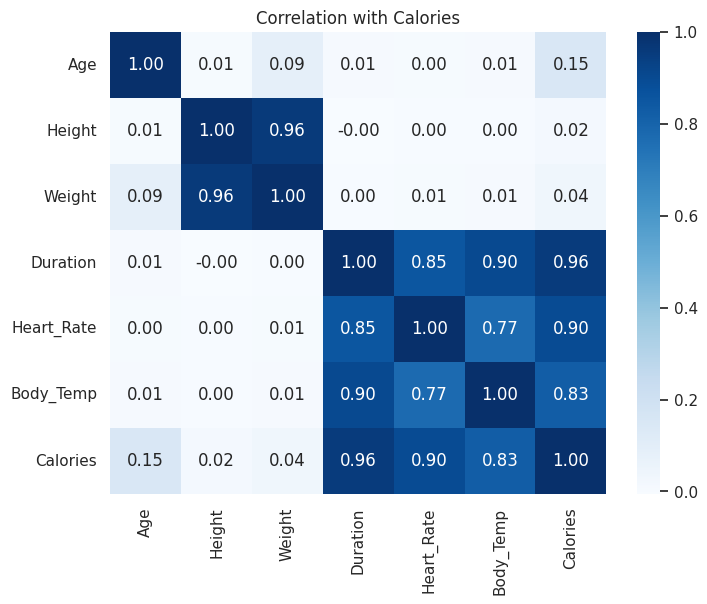

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation with Calories')
plt.show()

## 4. Feature Engineering

- `BMI` = Weight / (Height in metres)^2 — combines height and weight into one body-composition signal.

Applied identically to train and test.

In [11]:
def add_features(data):
    data = data.copy()
    data['BMI'] = data['Weight'] / (data['Height'] / 100) ** 2
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
X_train.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI
1154,female,38,169.0,67.0,3.0,85.0,38.5,23.458562
9804,male,30,194.0,96.0,9.0,91.0,39.6,25.507493
7919,female,78,182.0,79.0,7.0,84.0,39.4,23.849777
4854,male,50,171.0,77.0,29.0,111.0,40.8,26.332889
5947,female,32,172.0,66.0,29.0,105.0,40.8,22.309356


## 5. Encoding (One-Hot for nominal categoricals)

`Gender` is the only categorical column.

In [12]:
cat_cols = ['Gender']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
X_train.head()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,Gender_male
1154,38.0,169.0,67.0,3.0,85.0,38.5,23.458562,0.0
9804,30.0,194.0,96.0,9.0,91.0,39.6,25.507493,1.0
7919,78.0,182.0,79.0,7.0,84.0,39.4,23.849777,0.0
4854,50.0,171.0,77.0,29.0,111.0,40.8,26.332889,1.0
5947,32.0,172.0,66.0,29.0,105.0,40.8,22.309356,0.0


## 6. Outlier Handling — IQR vs Z-score vs Winsorization (auto-select best)

Applied to the **training set only**, on the continuous columns.

In [13]:
outlier_cols = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

# Honest evaluation: clean ONLY the sub-training fold, then score on an
# UNTOUCHED validation fold. This penalises methods (like winsorisation)
# that distort the training distribution but not the data seen at test time.
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=2)

def eval_method(clean_fn):
    Xc, yc = (X_tr, y_tr) if clean_fn is None else clean_fn(X_tr, y_tr, outlier_cols)
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    model.fit(Xc, yc)
    return r2_score(y_val, model.predict(X_val))  # X_val is left untouched

scores = {
    'none': eval_method(None),
    'iqr': eval_method(iqr_clean),
    'zscore': eval_method(zscore_clean),
    'winsorize': eval_method(winsor_clean),
}
for k, v in scores.items():
    print(f'{k:10s} val R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       val R2: 0.9970
iqr        val R2: 0.9971
zscore     val R2: 0.9970
winsorize  val R2: 0.9953

Best outlier method: iqr


In [14]:
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 11683


## 7. Feature Scaling — Standard vs MinMax vs Robust (auto-select best)

In [15]:
scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.9885
minmax     CV R2 (KNN): 0.9910
robust     CV R2 (KNN): 0.9853

Best scaler: minmax


## 8. Model Training & Comparison

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Random Forest,0.998189,1.695468,2.666767
1,Gradient Boosting,0.996097,2.823295,3.915188
2,KNN,0.992422,3.899067,5.455649
3,Linear Regression,0.968281,8.193321,11.161626


In [17]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 4))
print('Test RMSE  :', round(best_row['RMSE'], 4))

Best model : Random Forest
Test R2    : 0.9982
Test MAE   : 1.6955
Test RMSE  : 2.6668
